In [5]:
%run ./utils.ipynb

In [6]:
csv_path = "Agregados_por_setores_cor_ou_raca_BR_csv/Agregados_por_setores_cor_ou_raca_BR.csv"

In [11]:
# investigar Cidades com mais de x habitantes

In [42]:
desired_columns = [
    'CD_SETOR', 
    'V01317', 
    'V01318', 
    'V01319', 
    'V01320', 
    'V01321'
]

df = pd.read_csv(csv_path, sep = ';', usecols=desired_columns)
df['CD_SETOR'] = df['CD_SETOR'].astype('str')

cols_to_clean = ['V01317', 'V01318', 'V01319', 'V01320', 'V01321']
df[cols_to_clean] = df[cols_to_clean].replace('X', 0)
df = df.fillna(0)
df[cols_to_clean] = df[cols_to_clean].astype('int32')

df['pop_total'] = df[cols_to_clean].sum(axis=1)

C:\Users\renan\AppData\Local\Temp\ipykernel_49804\4209179137.py:10: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, sep = ';', usecols=desired_columns)


In [59]:
df['COD_MUNICIPIO'] = df['CD_SETOR'].str[:6]
df['COD_ESTADO'] = df['CD_SETOR'].str[:2]

In [60]:
df.head()

,CD_SETOR,V01317,V01318,V01319,V01320,V01321,pop_total,COD_MUNICIPIO,COD_ESTADO
0,110001505000002,312,87,0,514,13,926,110001,11
1,110001505000003,189,25,0,336,6,556,110001,11
2,110001505000004,71,14,0,135,0,220,110001,11
3,110001505000006,255,54,0,460,14,783,110001,11
4,110001505000007,229,49,0,459,10,747,110001,11


In [63]:
pop_total_municipios = df.groupby(['COD_MUNICIPIO','COD_ESTADO'])[['pop_total']].sum()

In [71]:
# 2. Filter for sums greater than a value{
municipios_grandes = pop_total_municipios[pop_total_municipios['pop_total'] > 100000].reset_index()

In [72]:
municipios_grandes

,COD_MUNICIPIO,COD_ESTADO,pop_total
0,110012,11,123674
1,110020,11,456992
2,120040,12,361827
3,130190,13,103249
4,130250,13,101702
...,...,...,...
314,521880,52,224767
315,522045,52,155397
316,522140,52,141589
317,522185,52,198578


In [19]:
estado = 'RS'
municipio = '4314902'

shp_path = f"shapefiles_2022/{estado}_setores_CD2022/{estado}_setores_CD2022.shp"

In [20]:
shp_path

'shapefiles_2022/RS_setores_CD2022/RS_setores_CD2022.shp'

In [23]:
filepath = shp_path
gdf = gpd.read_file(filepath)
gdf_cidade = gdf[gdf['CD_MUN'] == '4314902']

In [25]:
df = pd.read_csv(csv_path, sep = ';', usecols=desired_columns)
df['CD_SETOR'] = df['CD_SETOR'].astype('str')
merged_gdf = gdf_cidade.merge(df, on='CD_SETOR', how='left')

C:\Users\renan\AppData\Local\Temp\ipykernel_49804\1357846267.py:1: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, sep = ';', usecols=desired_columns)


In [26]:
merged_gdf.head()

,CD_SETOR,SITUACAO,CD_SIT,CD_TIPO,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,...,CD_RGI,NM_RGI,CD_CONCURB,NM_CONCURB,geometry,V01317,V01318,V01319,V01320,V01321
0,431490205000001,Urbana,1,0,0.081170,4,Sul,43,Rio Grande do Sul,4314902,...,430001,Porto Alegre,4314902,Porto Alegre/RS,"POLYGON ((-51.22685 -30.03026, -51.2269 -30.03...",163,28,X,25,0
1,431490205000002,Urbana,1,0,0.015490,4,Sul,43,Rio Grande do Sul,4314902,...,430001,Porto Alegre,4314902,Porto Alegre/RS,"POLYGON ((-51.22778 -30.03156, -51.22785 -30.0...",110,7,3,13,0
2,431490205000003,Urbana,1,0,0.007422,4,Sul,43,Rio Grande do Sul,4314902,...,430001,Porto Alegre,4314902,Porto Alegre/RS,"POLYGON ((-51.22785 -30.03156, -51.22952 -30.0...",373,33,4,37,X
3,431490205000004,Urbana,1,0,0.113515,4,Sul,43,Rio Grande do Sul,4314902,...,430001,Porto Alegre,4314902,Porto Alegre/RS,"POLYGON ((-51.2245 -30.0271, -51.22554 -30.027...",190,15,5,30,0
4,431490205000005,Urbana,1,0,0.066469,4,Sul,43,Rio Grande do Sul,4314902,...,430001,Porto Alegre,4314902,Porto Alegre/RS,"POLYGON ((-51.22463 -30.02869, -51.22467 -30.0...",317,45,3,67,3


C:\Users\renan\anaconda3\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files. Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()
C:\Users\renan\AppData\Local\Temp\ipykernel_49804\3701015944.py:15: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, sep = ';', usecols=desired_columns)
C:\Users\renan\AppData\Local\Temp\ipykernel_49804\3701015944.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_gdf = merged_gdf.fillna(0)


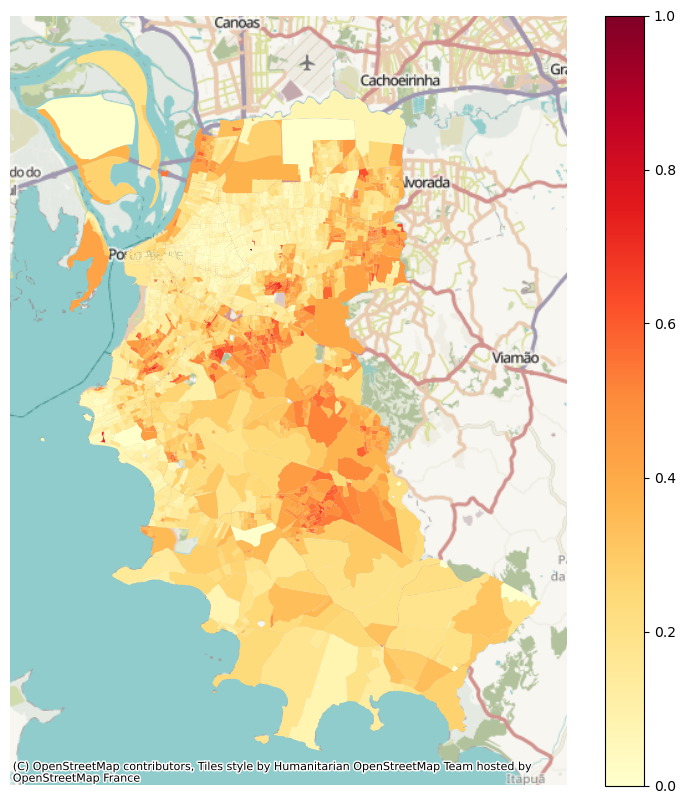

C:\Users\renan\anaconda3\Lib\site-packages\segregation\singlegroup\spatial_dissim.py:48: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_object = Queen.from_dataframe(data)


Dissimilarity: 0.36938877371482537
Spatial Dissimilarity: 0.2862184030564052
Gini: 0.48854095748836385
Entropy: 0.12980799191107342
Isolation: 0.36469467525756316
Dist. Decay Isolation: 0.32391461781522224
Rel. Concentration: -0.10650809891200008
Rel. Centralization: -0.10156531362133592
Rel. Clustering: 0.5956711862979596


In [10]:
seg_profile_mun(shp_path, csv_path, municipio, plot_dinamico = dummy_dinamico)